# MediScanX: CXR Inference & Explainability (Grad-CAM++)
**Project:** AI-Powered Multimodal Medical Scanner.<br>
**Objective:** Deploy the trained CIHMLC DenseNet121 model for single-image inference and extract spatial interpretability maps via Grad-CAM++.<br> 
**Infrastructure:** This notebook serves as the inference testing environment.

---

## Section 1: Inference Configuration

This section defines the centralized configuration for the inference pipeline. The `CXRInferenceConfig` dataclass strictly types the required file paths, model architecture specifications, and the target convolutional layer necessary for Grad-CAM++ feature extraction.

In [ ]:
import torch
import cv2
from dataclasses import dataclass, field

@dataclass
class CXRInferenceConfig:
    """Centralized configuration for the Chest X-Ray inference and explainability pipeline."""
    # Paths
    model_weights_path: str = "/kaggle/input/notebooks/d4phoenix/01-cxr-densenet-cihmlc/best_densenet_cihmlc.pth"
    kaggle_dataset_root: str = "/kaggle/input/datasets/ashery/chexpert"
    csv_test_path: str = "/kaggle/input/notebooks/d4phoenix/01-cxr-densenet-cihmlc/temp_splits/test_split.csv"
    
    # Architecture
    image_size: tuple[int, int] = (320, 320)
    num_classes: int = 14 
    pretrained: bool = False
    
    # Interpretability Settings
    heatmap_alpha: float = 0.6
    heatmap_beta: float = 0.4
    colormap: int = cv2.COLORMAP_JET
    
    # Clinical Decision Boundaries
    confidence_threshold: float = 0.5
    
    # Standard CheXpert labels in exact categorical order
    CHEXPERT_LABELS: list[str] = field(default_factory=lambda: [
        "No Finding", "Enlarged Cardiomediastinum", "Cardiomegaly", "Lung Opacity",
        "Lung Lesion", "Edema", "Consolidation", "Pneumonia", "Atelectasis", 
        "Pneumothorax", "Pleural Effusion", "Pleural Other", "Fracture", "Support Devices"
    ])
    
    # Hardware
    device: torch.device = field(
        default_factory=lambda: torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    )
    
cfg = CXRInferenceConfig()
print(f"Executing MediScanX CXR Inference on: {cfg.device}")
print("Centralized configuratoin for the inference pipeline defined.")

Executing MediScanX CXR Inference on: cpu
Centralized configuratoin for the inference pipeline defined.


## Section 2: Preprocessing Pipeline

This section establishes the deterministic preprocessing sequence required for clinical inference. It mirrors the exact `ApplyCLAHE` and base tensor transformations used during training to prevent data drift. Furthermore, it defines the `CXRInferencePreprocessor`, which acts as the entry point for raw images. This wrapper handles CPU-side ImageNet normalization and prepares the 4D batch tensor required for standard model ingestion, while preserving the raw image array for downstream Grad-CAM heatmap overlays.

In [7]:
import cv2
import numpy as np
import torch
from torchvision import transforms
import torchvision.transforms.functional as TF

class ApplyCLAHE:
    """
    A custom PyTorch transform that applies Contrast Limited Adaptive Histogram Equalization (CLAHE) to a medical image.
    
    This class standardizes radiographic inputs by normalizing illumination discrepancies and enhancing local contrast 
    within lung fields, mitigating artifacts from legacy X-ray machines.
    """
    
    def __init__(self, clip_limit: float = 2.0, tile_grid_size: tuple[int, int] = (8, 8)) -> None:
        """
        Initializes the ApplyCLAHE transform object.

        Args:
            clip_limit (float): Sets the threshold for contrast limiting.
            tile_grid_size (tuple[int, int]): Sets the grid size for localized equalization.
        """
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size
        self.clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
        
    def __call__(self, img: np.ndarray) -> np.ndarray:
        """
        Executes CLAHE and stacks the output into a 3-channel array for transfer learning.

        Args:
            img (np.ndarray): The input grayscale image array.

        Returns:
            np.ndarray: The contrast-enhanced, 3-channel RGB image array.
            
        Raises:
            TypeError: If the input is not a NumPy array. 
        """
        if not isinstance(img, np.ndarray):
            raise TypeError(f"ApplyCLAHE expects a numpy.ndarray, but got {type(img)}")
        
        # Ensure the image is 8-bit grayscale as required by OpenCV CLAHE
        if img.dtype != np.uint8:
            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
            img = img.astype(np.uint8)
            
        # Apply the CLAHE algorithm
        enhanced_img = self.clahe.apply(img)
        
        # Convert to 3-channel representation directly in OpenCV
        enhanced_img_3c = cv2.cvtColor(enhanced_img, cv2.COLOR_GRAY2RGB)
        
        return enhanced_img_3c
    
    def __repr__(self) -> str:
        """Return a string representation of the transform object."""
        return f"{self.__class__.__name__}(clip_limit={self.clip_limit}, tile_grid_size={self.tile_grid_size})"


class RadiographicPipeline:
    """
    A factory class constructing the base preprocessing pipeline for Chest X-Rays prior to model ingestion.
    Provides a unified transform sequence to ensure parity between training and inference environments.
    """
    
    @staticmethod
    def get_base_transforms(resize_dim: tuple[int, int] = (320, 320)) -> transforms.Compose:
        """
        Constructs the sequence of base transforms including CLAHE, tensor conversion, and resizing.

        Args:
            resize_dim (tuple[int, int]): Target dimensions for the neural network.

        Returns:
            transforms.Compose: The chained PyTorch transformations.
        """
        return transforms.Compose([
            ApplyCLAHE(clip_limit=2.0, tile_grid_size=(8, 8)),
            transforms.ToTensor(),
            transforms.Resize(resize_dim, antialias=True)
        ])
        
class CXRInferencePreprocessor:
    """Deterministic clinical preprocessing pipeline for single-image inference."""
    def __init__(self, cfg: CXRInferenceConfig) -> None:
        """
        Initializes the inference preprocessor
        
        Args:
            cfg (CXRInferenceConfig): The global inference configuration object.
        """
        self.cfg = cfg
        self.base_transforms = RadiographicPipeline.get_base_transforms(self.cfg.image_size)
        # ImageNet Normalization Stats (Replicates 'gpu_val_aug' from the training engine)
        self.mean = [0.485, 0.456, 0.406]
        self.std = [0.229, 0.224, 0.225]
        
    def process(self, image_path: str) -> tuple[torch.Tensor, np.ndarray]:
        """
        Applies the exact clinical preprocessing sequence required for model ingestion.

        Args:
            image_path (str): The absolute or relative path to the x-ray image.

        Returns:
            tuple[torch.Tensor, np.ndarray]: 
                - batched_tensor: A 4D model-ready tensor [1, 3, H, W]
                - visual_base: The CLAHE-enhanced RGB Numpy array for Grad-CAM overlays
                
        Raises:
            FileNotFoundError: If the specified image path does not exist or is unreadable.
        """
        raw_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        if raw_img is None:
            raise FileNotFoundError(f"OpenCV could not find or read the image at: {image_path}")
        
        # Phase 1: Base Pipeline (Strict Parity with Training)
        # ApplyCLAHE -> ToTensor -> Resize. Yields a [3, H, W] tensor in range [0.0, 1.0].
        base_tensor = self.base_transforms(raw_img)
        
        # Phase 2: Visual Base Extraction for Dashboard
        # Capture the image state *after* CLAHE and Resize, but *before* ImageNet normalization.
        # Permute from [C, H, W] back to [H, W, C] and scale to 8-bit integer.
        visual_base = (base_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        
        # Phase 3: Hardware Augmentation Parity (Normalization)
        # Apply the statistical normalization that was handled on the GPU during training.
        normalized_tensor = TF.normalize(base_tensor, mean=self.mean, std=self.std)
        
        # Phase 4: Add Batch Dimension
        batched_tensor = normalized_tensor.unsqueeze(0)
        
        return batched_tensor, visual_base
    
print("Preprocessing pipeline initialized successfully.")

Preprocessing pipeline initialized successfully.


## Section 3: Model Architecture (DenseNet121_CIHMLC)

This section reconstructs the exact computer vision architecture utilized during the training phase. Defining the identical class structure is a strict requirement for PyTorch to successfully map and load the trained `.pth` state dictionary. The dual-output `forward` method is explicitly designed to yield both the classification logits and the deep spatial feature maps required by the downstream Grad-CAM++ explainability engine.

In [3]:
import torch
import torch.nn as nn
import torchvision.models as models

class DenseNet121_CIHMLC(nn.Module):
    """
    Clinically-Inspired Hierarchical Multi-Label Classification Model.
    
    Utilizes a DenseNet121 backbone optimized for feature reuse. The architecture features
    a custom convolutional head and a dual-output forward pass to enable offline 
    Explainable AI (Grad-CAM++) on mobile edge devices.
    
    Attributes:
        features (nn.Sequential): The foundational DenseNet121 feature extractor blocks.
        custom_conv (nn.Conv2d): Dimensionality reduction and fine structural extraction layer.
        bn (nn.BatchNorm2d): Batch normalization for the custom convolutional head.
        relu (nn.ReLU): Non-linear activation for the custom conv layer.
        global_avg_pool (nn.AdaptiveAvgPool2d): Condenses spatial dimensions to (1, 1).
        dropout (nn.Dropout): Regularization layer.
        classifier (nn.Linear): The final dense layer mapping to the clinical pathologies.
    """
    def __init__(self, num_classes: int = 14, pretrained: bool = False) -> None:
        """
        Initializes the DenseNet121_CIHMLC architecture.

        Args:
            num_classes (int, optional): The number of output diagnostic labels. Defaults to 14.
            pretrained (bool, optional): Whether to initialize with ImageNet weights. 
                                        Defaults to False for inference, as we load custom weights
        """
        super().__init__()
        
        # Load the foundation DenseNet121 backbone
        weights = models.DenseNet121_Weights.DEFAULT if pretrained else None
        densenet = models.densenet121(weights=weights)
        
        # Extract the feature blocks
        self.features = densenet.features
        
        # Append Custom Conv2D Layer
        # DenseNet121's feature extractor naturally outputs 1024 channels.
        # We compress this to 512 filters to extract finer structural details and reduce parameters
        self.custom_conv = nn.Conv2d(
            in_channels=1024,
            out_channels=512,
            kernel_size=3,
            padding=1,
            bias=False
        )
        
        # BatchNorm and ReLU for stabilization for non-linearity
        self.bn = nn.BatchNorm2d(512)
        self.relu = nn.ReLU(inplace=True)
        
        # Global Average Pooling: Condenses the spatial dimensions (H,W) to (1,1) while preserving the 512 feature maps
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Add dropout for regularization
        self.dropout = nn.Dropout(p=0.4)
        self.classifier = nn.Linear(in_features=512, out_features=num_classes)
    
    def forward(self, x: torch.Tensor) -> tuple:
        """
        Execute the dual-output forward pass.

        Args:
            x (torch.Tensor): A batch of 3-channel X-ray images.

        Returns:
            tuple: 
                - logits (torch.Tensor): The raw, unactivated classification scores. Shape: [B, 14]
                - spatial_features (torch.Tensor): The raw spatial maps for Grad-CAM++. Shape: [B, 512, H', W']
        """
        # Pass through the DenseNet blocks
        x = self.features(x)
        
        # Pass through the custom structural extraction head
        spatial_features = self.relu(self.bn(self.custom_conv(x)))
        
        # Pool, flatten and classify
        pooled = self.global_avg_pool(spatial_features)
        flattened = torch.flatten(pooled, 1)
        
        # Apply the dropout before the final layer
        flattened = self.dropout(flattened)
        logits = self.classifier(flattened)
        
        # Return both artifacts for the inference engine
        return logits, spatial_features
    
print("DenseNet121 CIHMLC Model Architecture defined successfully.")

DenseNet121 CIHMLC Model Architecture defined successfully.


## Section 4: The Interpretability Engine (Grad-CAM++)

This section implements the **Grad-CAM++ (Generalized Gradient-weighted Class Activation Mapping)** engine. This approach is mathematically superior for medical imaging as it can effectively localize multiple instances of a pathology (e.g., scattered lung nodules) and provides a more precise spatial "fit" to anatomical boundaries.

In [ ]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F

class GradCAMPlusPlus:
    """
    Adaptive Grad-CAM++ Engine for clinical diagnostic explainability.
    
    Synthesizes higher-order gradients and spatial feature maps to generate 
    precise diagnostic heatmaps. Automatically inverts gradient flow for 
    low-confidence predictions to highlight Counter-Evidence.
    """
    def __init__(self, cfg: CXRInferenceConfig) -> None:
        """
        Initializes the GradCAM++ visualizer with blending configurations.

        Args:
            cfg (CXRInferenceConfig): The global inference configuration containing visual weights.
        """
        self.cfg = cfg
        
    def generate_heatmap(self, logits: torch.Tensor, spatial_features: torch.Tensor, target_idx: int) -> np.ndarray:
        """
        Computes a pixel-wise Grad-CAM++ heatmap using 2nd and 3rd order gradients.
        
        Args:
            logits (torch.Tensor): Raw model output scores [1, num_classes].
            spatial_features (torch.Tensor): Spatial maps from the model [1, C, H, W].
            target_idx (int): The index of the clinical pathology to be explained.

        Returns:
            np.ndarray: A normalized 2D heatmap [0.0 to 1.0] representing importance.
        """
        # Isolate the logits score and calculate absolute probability
        score = logits[0, target_idx]
        prob = torch.sigmoid(score).item()
        
        # Extract first-order gradients using stateless autograd
        try:
            gradients = torch.autograd.grad(
                outputs=score,
                inputs=spatial_features,
                retain_graph=True
            )[0]
        except RuntimeError as e:
            raise RuntimeError(
                "Autograd failed. Ensure 'requires_grad=True' was set for inputs and "
                "inference was not performed inside a 'torch.no_grad()' block." 
            ) from e
            
        # If the model is confident the disease is ABSENT (< 50%), we flip the gradients.
        if prob < 0.50:
            gradients = -gradients
            
        # Higher Order Derivatives
        activations = spatial_features.detach()
        grad_2 = gradients.pow(2)
        grad_3 = gradients.pow(3)
        
        # Calculate the denominator for the alpha weights using the original scaling behavior
        global_sum = activations * grad_3.sum(dim=(2, 3), keepdim=True)
        denominator = 2 * grad_2 + global_sum
        
        # Avoid division by zero for numerical stability
        denominator = torch.where(denominator != 0.0, denominator, torch.ones_like(denominator))
        
        # Calculate the pixel-level importance weights (alphas)
        alphas = grad_2 / denominator
        
        # Global Channel Weights calculation using ReLU'd gradients
        weights = (alphas * torch.relu(gradients)).sum(dim=(2, 3), keepdim=True)
        
        # Generate Linear Combination heatmap
        heatmap = (weights * activations).sum(dim=1).squeeze()
        
        # Apply ReLU to retain only positive spatial influence
        heatmap = F.relu(heatmap)
        heatmap_np = heatmap.cpu().numpy()
        
        # Apply Min-Max Normalization to scale values precisely between [0.0, 1.0]
        h_min, h_max = heatmap_np.min(), heatmap_np.max()
        if h_max - h_min > 1e-8:
            heatmap_np = (heatmap_np - h_min) / (h_max - h_min)
        else:
            heatmap_np = np.zeros_like(heatmap_np)
            
        return heatmap_np
    
    def blend_overlay(self, visual_base_rgb: np.ndarray, heatmap: np.ndarray) -> np.ndarray:
        """
        Resizes and blends the mathematical heatmap over the grayscale X-ray using Smart Alpha.

        Args:
            visual_base_rgb (np.ndarray): The CLAHE-enhanced RGB base image.
            heatmap (np.ndarray): The 2D importance map [0.0 to 1.0].

        Returns:
            np.ndarray: A color image with the heatmap blended over the anatomy.
        """
        # Upsample heatmap to match the 320x320 original radiographic resolution
        heatmap_rescaled = cv2.resize(heatmap, (visual_base_rgb.shape[1], visual_base_rgb.shape[0]))
        
        # Apply pseudocolor mapping (JET converts 0 to dark blue)
        heatmap_uint8 = np.uint8(255 * heatmap_rescaled)
        heatmap_colored_bgr = cv2.applyColorMap(heatmap_uint8, self.cfg.colormap)
        heatmap_colored_rgb = cv2.cvtColor(heatmap_colored_bgr, cv2.COLOR_BGR2RGB)
        
        # Convert images to float32 for precise mathematical blending
        base_f32 = visual_base_rgb.astype(np.float32)
        heat_f32 = heatmap_colored_rgb.astype(np.float32)
        
        # Create the dynamic mask based on the raw heatmap activation intensity [0.0, 1.0]
        mask = heatmap_rescaled[..., np.newaxis] 
        
        # If activation is 0.0, effective_alpha is 0.0 (fully transparent).
        # If activation is 1.0, effective_alpha is 0.4 (configured opacity).
        effective_alpha = mask * self.cfg.heatmap_beta
        
        # Mathematical Blending: (Base * (1 - Alpha)) + (Heatmap * Alpha)
        overlay = (base_f32 * (1.0 - effective_alpha)) + (heat_f32 * effective_alpha)
        
        # Clip safely back to 8-bit integer space
        return np.clip(overlay, 0, 255).astype(np.uint8)
    
print("Adaptive Grad-CAM++ Interpretability Engine Initialized.")

Adaptive Grad-CAM++ Interpretability Engine Initialized.


## Section 5: Clinical Diagnostic Engine

This section defines the `CXRDiagnosticEngine`, the centralized orchestration layer for the inference pipeline. It encapsulates the end-to-end logic required to transform a raw radiographic image into a clinical diagnostic report. By integrating the preprocessor, the CIHMLC architecture, and the Grad-CAM++ engine, this engine provides a unified interface that returns both structured probability scores and visual evidence (heatmaps), ensuring that the final output is both accurate and explainable.

In [1]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Any

class CXRDiagnosticEngine:
    """
    Orchestration engine for Chest X-Ray inference and diagnostic visualization.
    
    This engine coordinates the data flow between the preprocessor, the neural network,
    and the interpretability engine to produce evidence-based radiographic assessments.
    """
    def __init__(
        self,
        cfg: CXRInferenceConfig,
        model: torch.nn.Module,
        preprocessor: CXRInferencePreprocessor,
        xai_engine: GradCAMPlusPlus
    ) -> None:
        """
        Initializes the diagnostic engine with its constituent components.

        Args:
            cfg (CXRInferenceConfig): Global configuration for inference settings.
            model (nn.Module): The loaded CIHMLC DenseNet121 model.
            preprocessor (CXRInferencePreprocessor): Component for radiographic standardization.
            xai_engine (GradCAMPlusPlus): Component for spatial feature localization.
        """
        self.cfg = cfg
        self.model = model.to(self.cfg.device)
        self.preprocessor = preprocessor
        self.xai_engine = xai_engine
        self.model.eval()
        
    def run_diagnostic(self, image_path: str, top_k: int=5) -> Dict[str, Any]:
        """
        Executes a complete diagnostic pass on X-ray image.

        Args:
            image_path (str): The path to the raw patient X-ray.
            top_k (int): Number of top pathologies to analyze and generate XAI for.

        Returns:
            Dict [str, Any]: Structure diagnostic payload containing probabilities,
                            the raw image, and Grad-CAM++ overlay arrays.
        
        Raises:
            RuntimeError: If the model forward pass or gradient calculation fails.
        """
        # Apply preprocessing on the raw image to retrieve 4D Tensor and original image
        input_tensor, visual_base_rgb = self.preprocessor.process(image_path)
        input_tensor = input_tensor.to(self.cfg.device)
        
        # Enable gradients for the input tensor as Grad-CAM++ requires the computation graph
        input_tensor.requires_grad = True
        
        # Model Forward Pass
        logits, spatial_features = self.model(input_tensor)
        
        # Probability Computation
        probs = torch.sigmoid(logits).squeeze().detach().cpu().numpy()
        
        # Identify Top-K Predictions
        top_indices = np.argsort(probs)[::-1][:top_k]
        
        # Generate Explainability Evidence
        top_findings = []
        for class_idx in top_indices:
            score = float(probs[class_idx])
            label = self.cfg.CHEXPERT_LABELS[class_idx]
            
            # Generate the specific Grad-CAM++ heatmap for the disease
            heatmap = self.xai_engine.generate_heatmap(logits, spatial_features, class_idx)
            overlay = self.xai_engine.blend_overlay(visual_base_rgb, heatmap)
            
            top_findings.append({
                "label": label,
                "confidence": score,
                "overlay_img": overlay
            })
        
        return {
            "original_img": visual_base_rgb,
            "top_findings": top_findings,
            "patient_id": image_path.split('/')[-1]
        }
        
    def visualize_evaluation_dashboard(self, results: Dict[str, Any], true_labels: List[float]=None) -> None:
        """
        Generates a professional clinical dashboard for academic review and debugging.

        Args:
            results (Dict[str, Any]): The output payload from run_diagnostic().
            true_labels (List[float], optional): Ground truth array [14] from the test set.
                                                Used to cross-reference model accuracy.
        """
        top_findings = results["top_findings"]
        num_plots = len(top_findings) + 1
        
        # Format Ground Truth test for the report header
        gt_text = "Unknown"
        active_gt = []
        if true_labels is not None:
            active_gt = [self.cfg.CHEXPERT_LABELS[i] for i, val in enumerate(true_labels) if val == 1.0]
            gt_text = ", ".join(active_gt) if active_gt else "Healthy (No Findings)"
        
        # Initialize the Academic Figure Layout
        fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 6))
        fig.suptitle(
            f"MediScanX Clinical Assessment | Patient ID: {results['patient_id']}\n"
            f"Ground Truth: {gt_text}",
            fontsize=20, fontweight='bold', y=1.08
        )
        
        # Panel 1: Original Standardized Radiograph
        axes[0].imshow(results["original_img"], cmap='gray')
        axes[0].set_title("Original Radiograph\n(CLAHE Enhanced)", fontsize=16, fontweight='bold')
        axes[0].axis('off')
        
        # Panels 2 to N: Top-K Grad-CAM++ Heatmaps
        for i, finding in enumerate(top_findings):
            axes[i + 1].imshow(finding["overlay_img"])
            
            label = finding["label"]
            prob = finding["confidence"]
            
            # Add an asterisk if the model correctly identified a ground truth pathology
            match_star = "* " if label in active_gt else ""
            
            # Color-code confidence (Red for high alert, Green for low probability)
            if prob > 0.50:
                text_color = "darkred"
                evidence_type = "Positive Evidence"
            else:
                text_color = "forestgreen"
                evidence_type = "Counter-Evidence"
                
            axes[i + 1].set_title(
                f"{match_star}{label}\nConf: {prob*100:.1f}%\n({evidence_type})",
                fontsize=14, fontweight='bold', color=text_color
            )
            axes[i + 1].axis('off')
            
        plt.tight_layout()
        plt.show()
        
print("Clinical Diagnostic Engine initialized.")

ModuleNotFoundError: No module named 'torch'

## Section 6: Pipeline Execution & Clinical Evaluation
**Objective:** End-to-End System Validation

This final execution block instantiates the complete MediScanX inference pipeline. It initializes the configuration, loads the optimized CIHMLC model weights from the NVMe storage, and instantiates the `CXRDiagnosticEngine`.

Initializing MediScanX Pipeline Components...
Allocating CIHMLC architecture on cpu...
SUCCESS: Model weights perfectly mapped and loaded!
Loading clinical records from: /kaggle/input/notebooks/d4phoenix/01-cxr-densenet-cihmlc/temp_splits/test_split.csv
Executing diagnostic pass on 3 patient records...
------------------------------------------------------------


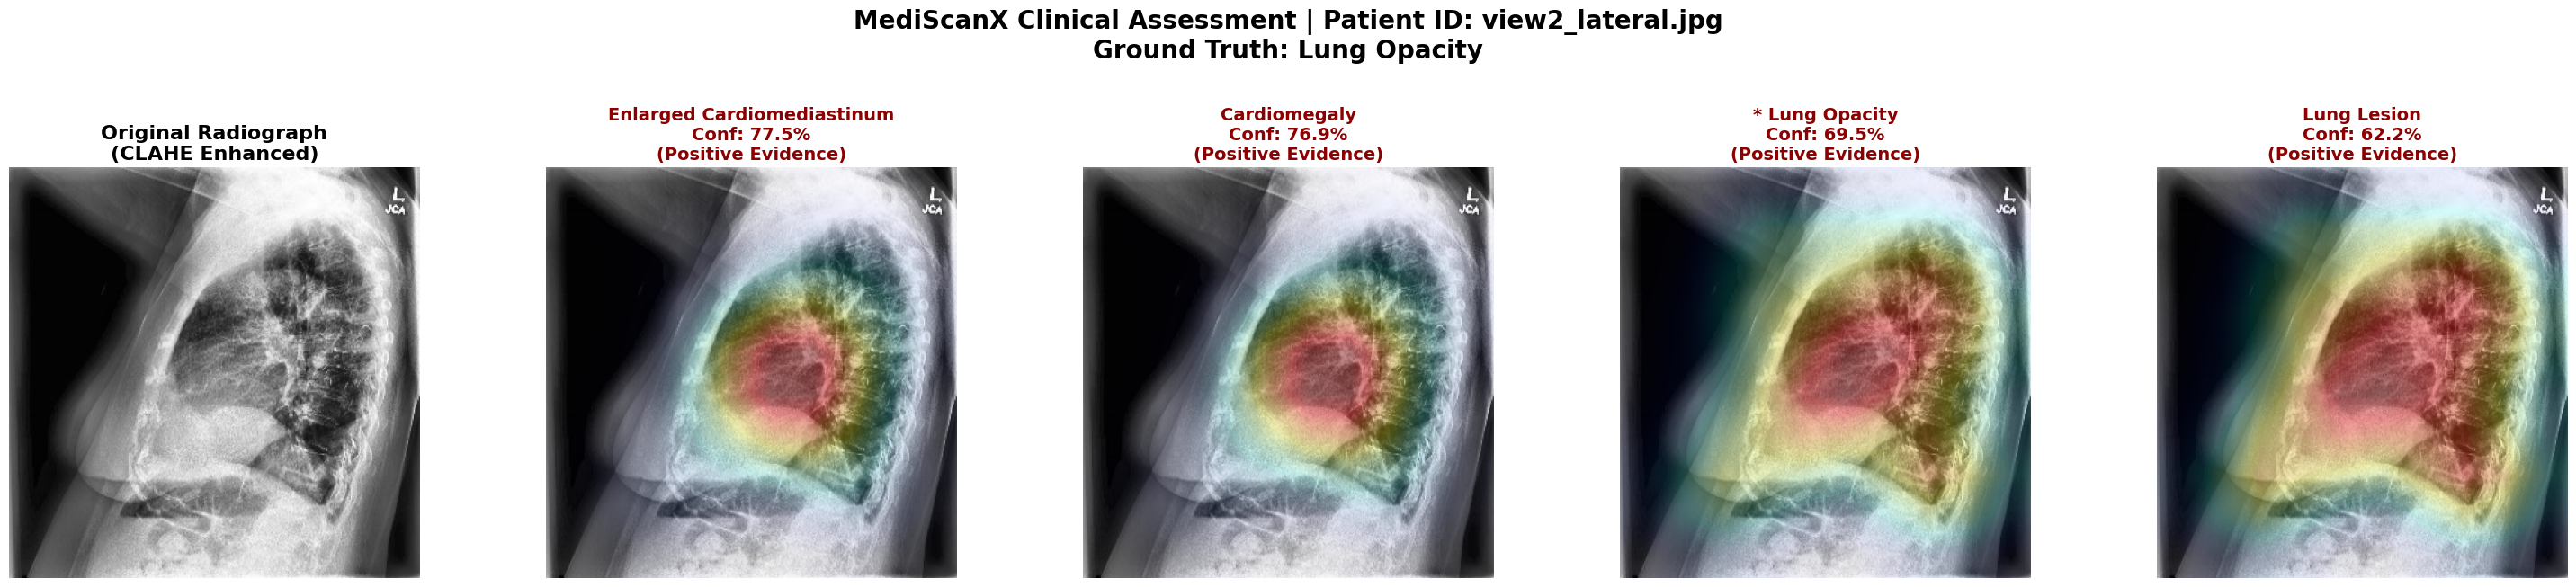

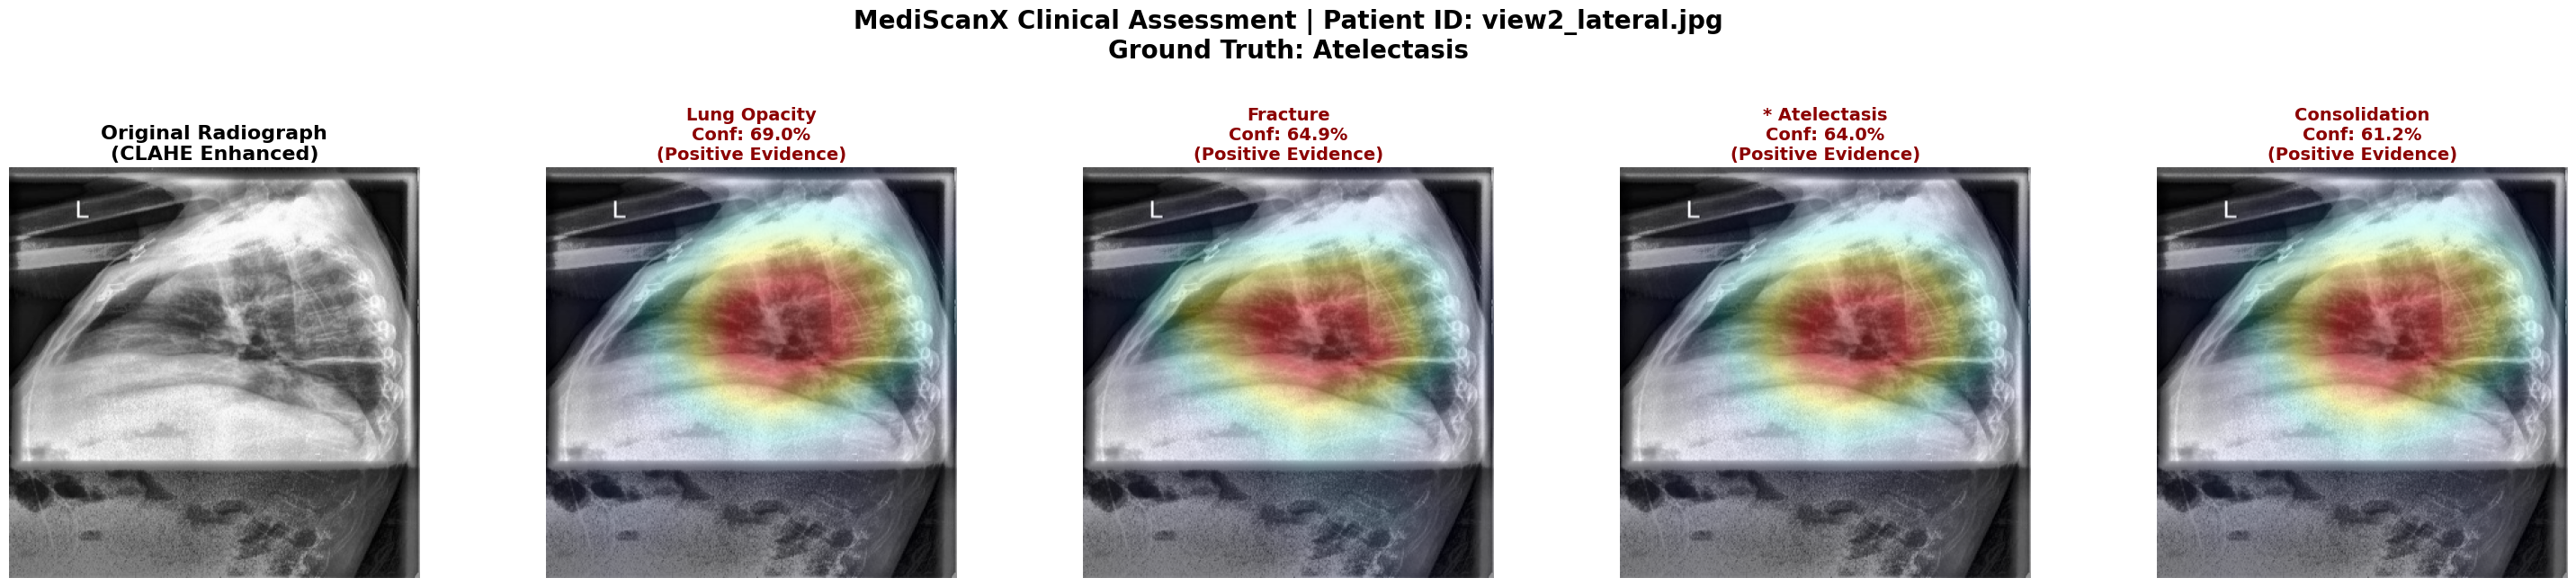

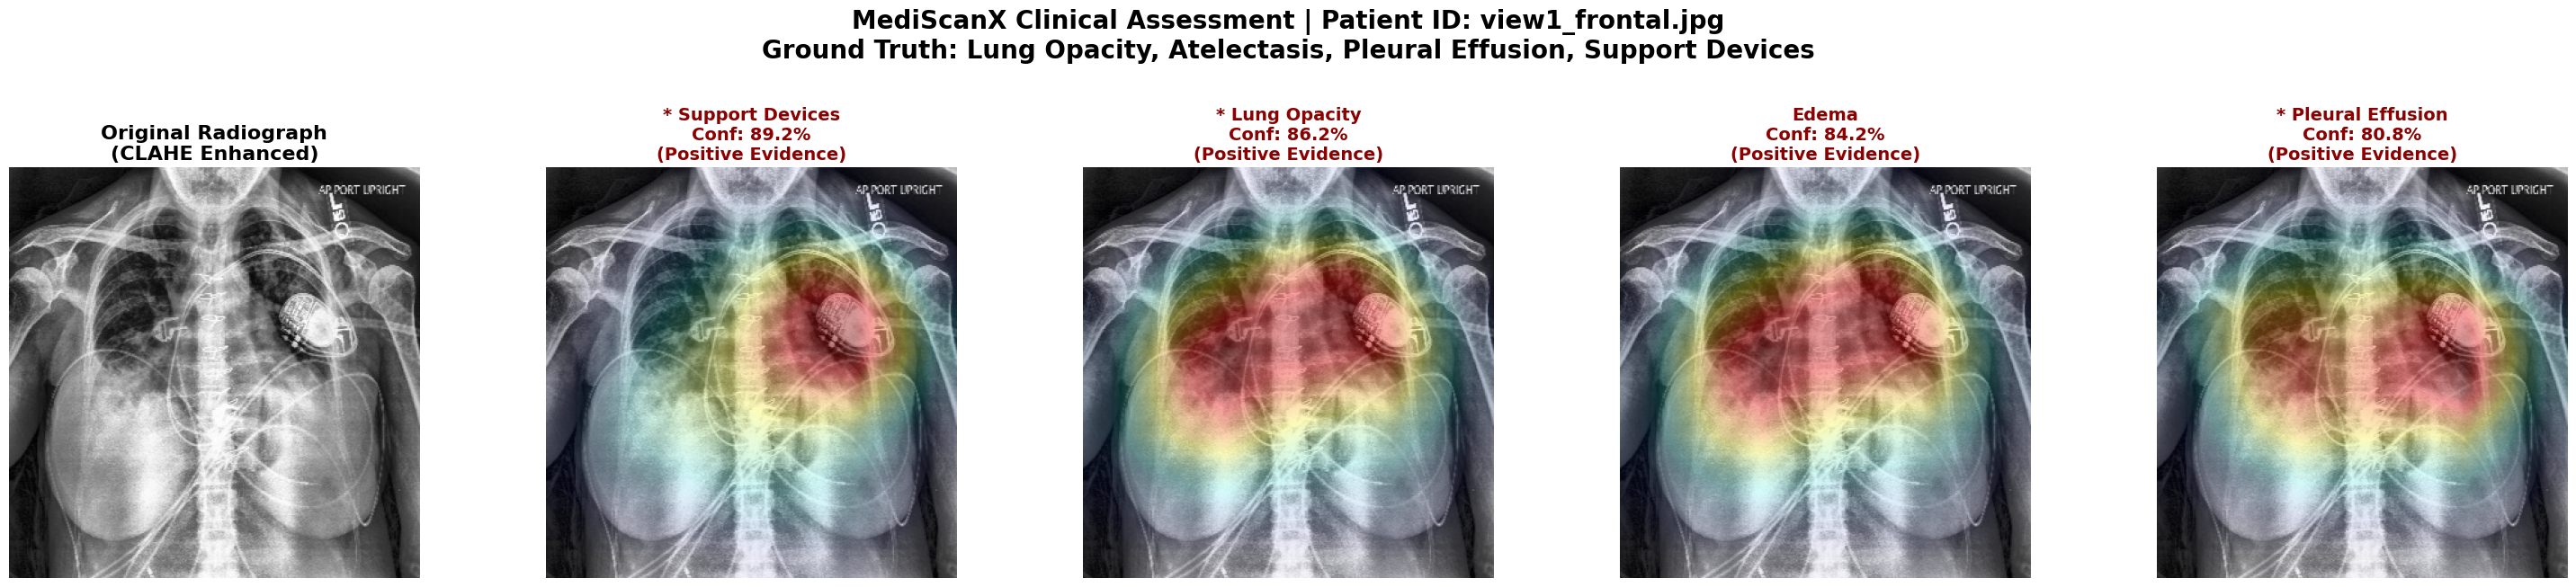

In [27]:
import os
import torch
import pandas as pd
from collections import OrderedDict
from typing import Optional

def load_production_model(cfg: CXRInferenceConfig) -> torch.nn.Module:
    """
    Factory function to instantiate the model and safely load weights, 
    stripping any compiler or multi-GPU prefixes.
    """
    print(f"Allocating CIHMLC architecture on {cfg.device}...")
    model = DenseNet121_CIHMLC(num_classes=cfg.num_classes, pretrained=False)
    
    try:
        raw_state_dict = torch.load(cfg.model_weights_path, map_location=cfg.device, weights_only=True)
        
        if 'model_state_dict' in raw_state_dict:
            raw_state_dict = raw_state_dict['model_state_dict']
            
        # Clean compiler and parallel hardware prefixes
        clean_state_dict = OrderedDict()
        for k, v in raw_state_dict.items():
            name = k.replace('_orig_mod.', '').replace('module.', '')
            clean_state_dict[name] = v
            
        model.load_state_dict(clean_state_dict)
        print(f"SUCCESS: Model weights perfectly mapped and loaded!")
        return model

    except FileNotFoundError as e:
        raise FileNotFoundError(
            f"CRITICAL ERROR: Weights not found at {cfg.model_weights_path}.\n"
            f"Please check your path configuration."
        ) from e
    except RuntimeError as e:
        raise RuntimeError(f"Weight mapping failed: {e}") from e

def run_academic_evaluation(cfg: CXRInferenceConfig, num_samples: int = 3) -> None:
    """
    Simulates a production environment by orchestrating the engine 
    and running a batch evaluation for academic visualization.
    """
    print("Initializing MediScanX Pipeline Components...")
    
    # Initialize Components
    preprocessor = CXRInferencePreprocessor(cfg)
    xai_engine = GradCAMPlusPlus(cfg)
    cxr_model = load_production_model(cfg)
    
    diagnostic_engine = CXRDiagnosticEngine(cfg, cxr_model, preprocessor, xai_engine)
    
    # Load Clinical Records
    try:
        print(f"Loading clinical records from: {cfg.csv_test_path}")
        df_test = pd.read_csv(cfg.csv_test_path)
        
        sample_patients = df_test.sample(n=num_samples, random_state=42)
        print(f"Executing diagnostic pass on {len(sample_patients)} patient records...\n" + "-"*60)
        
        # Execution Loop
        for index, row in sample_patients.iterrows():
            relative_path = row['Path'].replace('CheXpert-v1.0-small/', '')
            full_image_path = os.path.join(cfg.kaggle_dataset_root, relative_path)
            
            if os.path.exists(full_image_path):
                # Extract ground truth seamlessly
                true_labels = [
                    float(row[label]) if pd.notna(row[label]) else 0.0 
                    for label in cfg.CHEXPERT_LABELS
                ]
                
                # Execute Core & Shell
                api_payload = diagnostic_engine.run_diagnostic(full_image_path, top_k=4)
                diagnostic_engine.visualize_evaluation_dashboard(api_payload, true_labels)
                
            else:
                print(f"Warning: Image file not found at {full_image_path}.")

    except FileNotFoundError:
        print(f"CRITICAL ERROR: Could not find the test CSV at {cfg.csv_test_path}.")
    except KeyError as e:
        print(f"CSV Parsing Error: Column {e} not found in the dataset.")

if __name__ == "__main__":
    global_cfg = CXRInferenceConfig()
    run_academic_evaluation(global_cfg, num_samples=3)